# TEST NOTEBOOK

In [1]:
import diffrax as dfx
import distrax as dsx
import equinox as eqx
import jax
import jax.numpy as jnp

from superiorflows import Flow

key = jax.random.PRNGKey(0)
d = (4,2)
M = 3
low = -jnp.ones(d)
high = jnp.ones(d)
uniform_dist = dsx.Independent(dsx.Uniform(low, high), reinterpreted_batch_ndims=len(d))
key, subkey = jax.random.split(key)
X0 = uniform_dist.sample(seed=subkey, sample_shape=(M,))
jax.vmap(uniform_dist.log_prob)(X0)

class VelocityField(eqx.Module):
    params: jax.Array

    def __call__(self, t, x, args):
        return -t * x @ self.params.T

key, subkey = jax.random.split(key)
params = jax.random.normal(subkey, (d[1], d[1]))
velocity_field = VelocityField(params=params)
t = 1.0
key, subkey = jax.random.split(key)
x = uniform_dist.sample(seed=subkey)
velocity_field(t, x, None)

flow = Flow(velocity_field=velocity_field, base_distribution=uniform_dist, dt0=0.1,
            extra_args={'max_steps':1000})
flow.integrate(x, dt0=0.01)
flow.apply_map(x)
flow.apply_inverse_map(x)
flow = Flow(
    velocity_field=velocity_field,
    base_distribution=uniform_dist,
    stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
    )
jnp.allclose(flow.apply_inverse_map(flow.apply_map(x0=x)), x, atol=1e-5, rtol=1e-5)

Array(True, dtype=bool)

In [2]:
M = 3
X0 = uniform_dist.sample(seed=subkey, sample_shape=(M,))
X1 = jax.vmap(flow.apply_map)(X0)
assert jnp.allclose(flow.apply_inverse_map(X1), X0, atol=1e-5, rtol=1e-5)
X1, logq1 = jax.vmap(flow.apply_map_and_log_prob)(X0)
assert X1.shape == (M,) + X0.shape[1:]
assert logq1.shape == (M,)
assert flow.log_prob(X1).shape == (M,)
assert jnp.allclose(flow.apply_inverse_map(X1), X0, atol=1e-4, rtol=1e-4)

In [24]:
@eqx.filter_jit
def foo_loss(flow, X0):
    X1, logq1 = jax.vmap(flow.apply_map_and_log_prob)(X0)
    return jnp.sum(logq1)

M = 3
key, subkey = jax.random.split(key)
X0 = flow.base_distribution.sample(seed=subkey, sample_shape=(M,))
foo_loss(flow, X0)

jax.grad(foo_loss)(flow, X0).velocity_field.params


Array([[6., 0.],
       [0., 6.]], dtype=float32)

In [13]:
@eqx.filter_jit
def foo_loss(flow, key):
    M = 3
    key, subkey = jax.random.split(key)
    X0 = flow.base_distribution.sample(seed=subkey, sample_shape=(M,))
    X1 = flow.apply_map(X0)
    return jnp.sum(X1)


## Particles

In [2]:
from typing import Optional

import diffrax as dfx
import distrax as dsx
import equinox as eqx
import jax
import jax.numpy as jnp

from superiorflows import Flow


class System(eqx.Module):
    positions: jnp.ndarray
    species: jnp.ndarray
    box: jnp.ndarray
    temperature: Optional[float] = eqx.field(static=True, default=None)

    @property
    def N(self):
        return self.positions.shape[-2]

    @property
    def d(self):
        return self.positions.shape[-1]

class ParticlesVelocityField(eqx.Module):
    params: jax.Array

    def __call__(self, t, system: System, args=None):
        vr = -t * system.positions @ self.params.T
        vs = jnp.zeros_like(system.species)
        return System(
            positions=vr,
            species=vs,
            box=jnp.zeros_like(system.box),
            temperature=system.temperature,
            )

key = jax.random.PRNGKey(0)
system = System(jnp.array([[1.5, 1.2], [2.1, 2.3], [3.2, 4.1]]), jnp.array([1.0, 1.0, 1.4]), jnp.array([5.0, 5.0]), temperature=1.0)
key, subkey = jax.random.split(key)
velocity_field = ParticlesVelocityField(params=jax.random.uniform(subkey, (2,2)))
velocity_field(0.0, system)

System(positions=f32[3,2], species=f32[3], box=f32[2], temperature=1.0)

In [3]:
filter = eqx.tree_at(
            lambda x: (x.positions, x.species, x.box),
            system,
            replace=(True, True, False)
        )

flow = Flow(
    velocity_field=velocity_field,
    base_distribution=None,
    stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
    dynamic_mask=filter,
    )
flow.apply_map(system)

System(positions=f32[3,2], species=f32[3], box=f32[2], temperature=1.0)

In [4]:
solver_args = dict(
    solver=flow.solver,
    t0=flow.t0,
    t1=flow.t1,
    dt0=flow.dt0,
    stepsize_controller=flow.stepsize_controller,
    **flow.extra_args,
)

x0 = system

y0, ctx = eqx.partition(x0, flow.dynamic_mask)
def _dynamics(t, y, args):
    x = eqx.combine(y, ctx)
    v = flow.velocity_field(t, x, args)
    dy, _ = eqx.partition(v, flow.dynamic_mask)
    return dy

term = dfx.ODETerm(_dynamics)
sol = dfx.diffeqsolve(term, y0=y0, **solver_args)


In [5]:
sol.ys

System(positions=f32[1,3,2], species=f32[1,3], box=None, temperature=1.0)

In [6]:
flow._merge_solution(sol.ys, ctx)

System(positions=f32[1,3,2], species=f32[1,3], box=f32[1,2], temperature=1.0)

In [7]:
ys = sol.ys
leaves = jax.tree.leaves(ys)
leaves
T = leaves[0].shape[0]


In [8]:
## Batches of particles?

batch_size = 3
N = 4
d = 2
box = jnp.array([5., 5.])

key = jax.random.PRNGKey(0)
key, *subkeys = jax.random.split(key, num=batch_size+1)
x1 = System(
    positions=jax.random.uniform(subkeys[0], shape=(N, d)),
    species=jnp.array([0, 1, 0, 1]),
    box=box,
    temperature=1.,
    )
x2 = System(
    positions=jax.random.uniform(subkeys[1], shape=(N, d)),
    species=jnp.array([1, 1, 0, 0]),
    box=box,
    temperature=1.,
    )
x3 = System(
    positions=jax.random.uniform(subkeys[2], shape=(N, d)),
    species=jnp.array([1, 0, 0, 1]),
    box=box,
    temperature=1.,
    )

list_of_systems = [x1, x2, x3]
test = jax.tree.map(lambda *vals: jnp.array(vals), *list_of_systems)
jax.vmap(flow.apply_map)(test).species

Array([[0., 1., 0., 1.],
       [1., 1., 0., 0.],
       [1., 0., 0., 1.]], dtype=float32)

In [ ]:
from typing import Optional

import distrax as dsx
import equinox as eqx
import jax
import jax.numpy as jnp

x = jnp.array([1.0, 2.0, 3.0])

state, ctx = eqx.partition(x, eqx.is_inexact_array)
state, ctx





Array([1., 2., 3.], dtype=float32)

In [9]:
from typing import Optional

import distrax as dsx
import equinox as eqx
import jax
import jax.numpy as jnp


class UniformSystem(eqx.Module, dsx.Distribution):
    box: jnp.ndarray
    ref_species: jnp.ndarray
    temperature: Optional[float] = eqx.field(static=True, default=None)

    def __init__(self, box: jax.Array, ref_species: jax.Array, temperature: float = None):
        self.box = box
        self.ref_species = ref_species
        self.temperature = temperature
        # Note: We do not call super().__init__ here as eqx.Module
        # handles the registration and distrax.Distribution is a mixin.

    @property
    def event_shape(self):
        # We return a System where the leaves are the shapes of the arrays
        return System(
            positions=(self.ref_species.shape[0], self.box.shape[0]),
            species=(self.ref_species.shape[0],),
            box=(self.box.shape[0],),
            temperature=None # Static field, generally ignored by JAX tree_map
        )

    def _sample_n(self, key, n):
        N = self.ref_species.shape[0]
        d = self.box.shape[0]

        k1, k2 = jax.random.split(key)

        # 1. Sample Positions: Uniform in [0, Box] -> Shape (n, N, d)
        # We assume the box starts at 0.
        pos = jax.random.uniform(k1, shape=(n, N, d), minval=0.0, maxval=self.box)

        # 2. Sample Species: Random permutations -> Shape (n, N)
        # We need independent permutations for each sample in the batch n.
        keys_perm = jax.random.split(k2, n)

        def _permute(k):
            return jax.random.permutation(k, self.ref_species)

        species = jax.vmap(_permute)(keys_perm)

        # 3. Construct System
        # We must replicate the box n times to match the batch structure (Struct of Arrays)
        # Or simply rely on broadcasting if your System class supports it.
        # Here we broadcast the box to (n, d) to be safe.
        batched_box = jnp.broadcast_to(self.box, (n, d))

        return System(
            positions=pos,
            species=species,
            box=batched_box,
            temperature=self.temperature
        )

    def log_prob(self, value: System):
        # value.positions is expected to be (..., N, d)
        # value.species is expected to be (..., N)

        N = self.ref_species.shape[0]
        d = self.box.shape[0]

        # 1. Calculate base Log-Probability (Uniform Density)
        # p(x) = 1 / V^N  => log p(x) = -N * log(V) = -N * sum(log(L_i))
        vol_log = jnp.sum(jnp.log(self.box))
        base_log_prob = -N * vol_log

        # 2. Check Spatial Constraints (0 <= pos <= box)
        # We check if ALL coordinates of ALL particles are within bounds.
        # This reduces over the last two dimensions (N, d).
        in_box = jnp.all((value.positions >= 0.0) & (value.positions <= self.box), axis=(-1, -2))

        # 3. Check Composition Constraints (Species are a permutation)
        # Since species are floats, we sort them and compare to the sorted reference.
        # We use allclose for float stability.
        # Sort along the last axis (N)
        sorted_val_species = jnp.sort(value.species, axis=-1)
        sorted_ref_species = jnp.sort(self.ref_species, axis=-1)

        # We check if they are close. Broadcasting handles the batch dim of value.species
        valid_composition = jnp.all(
            jnp.isclose(sorted_val_species, sorted_ref_species),
            axis=-1
        )

        # 4. Combine
        # If valid, return base_log_prob, else -inf.
        # base_log_prob is a scalar, masking broadcasts it to the batch shape.
        is_valid = in_box & valid_composition
        return jnp.where(is_valid, base_log_prob, -jnp.inf)

# --- Test Usage ---

# Define the reference (template) for the distribution
ref_radii = jnp.array([1.0, 1.0, 1.4])
box_dims = jnp.array([5.0, 5.0])

# Instantiate the distribution
dist = UniformSystem(box=box_dims, ref_species=ref_radii, temperature=1.0)

# 1. Sample n=4 systems
key = jax.random.PRNGKey(42)
samples = dist.sample(seed=key, sample_shape=(4,))

print(f"Sampled Positions Shape: {samples.positions.shape}") # Should be (4, 3, 2)
print(f"Sampled Species Shape:   {samples.species.shape}")   # Should be (4, 3)

# 2. Check Log Probabilities
log_probs = dist.log_prob(samples)
print(f"Log Probs: {log_probs}")

# Expected value calculation:
# Volume = 5 * 5 = 25. N = 3.
# log_prob = -3 * ln(25) = -3 * 3.2188... = -9.656...
expected_lp = -3 * jnp.sum(jnp.log(box_dims))
print(f"Expected LP: {expected_lp}")

Sampled Positions Shape: (4, 3, 2)
Sampled Species Shape:   (4, 3)
Log Probs: [-9.656628 -9.656628 -9.656628 -9.656628]
Expected LP: -9.656627655029297


In [13]:
samples = dist.sample(seed=key)
dist.event_shape.positions[0]

3

In [25]:
system = dist.sample(seed=key)

flow = Flow(
    velocity_field=velocity_field,
    base_distribution=dist,
    stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
    dynamic_mask=filter,
    )

flow.apply_map(system)

flow.apply_inverse_map(system)

flow.apply_map_and_log_prob(system)


(System(positions=f32[3,2], species=f32[3], box=f32[2], temperature=1.0),
 Array(-9.10293, dtype=float32))

In [28]:
samples = dist.sample(seed=key, sample_shape=(4,))
jax.vmap(flow.apply_map_and_log_prob)(samples)

(System(positions=f32[4,3,2], species=f32[4,3], box=f32[4,2], temperature=1.0),
 Array([-9.102928, -9.102928, -9.102928, -9.102928], dtype=float32))

## ML Training

In [1]:
import diffrax as dfx
import distrax as dsx
import equinox as eqx
import jax
import jax.numpy as jnp

from superiorflows import Flow


class CircularMixture(dsx.Distribution):
    """Circular mixture of 8 Gaussians implemented in Distrax."""

    def __init__(self, scale=0.7, radius=10.0):
        super().__init__()

        # 1. Define the geometry (8 points on a circle)
        # We mimic the PyTorch logic: x = sin(angle), y = cos(angle)
        angles = jnp.arange(8) * (jnp.pi / 4)
        locs = radius * jnp.stack([jnp.sin(angles), jnp.cos(angles)], axis=1)

        # 2. Define the mixture distribution (Uniform weights)
        mixture_dist = dsx.Categorical(probs=jnp.ones(8) / 8)

        # 3. Define the component distribution (8 Independent Gaussians)
        # We broadcast the scale to shape (8, 2)
        components_dist = dsx.MultivariateNormalDiag(
            loc=locs,
            scale_diag=jnp.full((8, 2), scale)
        )

        # 4. Compose them
        self.dist = dsx.MixtureSameFamily(
            mixture_distribution=mixture_dist,
            components_distribution=components_dist
        )

    @property
    def event_shape(self):
        """Returns the shape of a single sample (2D vector)."""
        return (2,)

    def _sample_n(self, key, n):
        """
        Samples n elements.
        
        Args:
            key: JAX PRNG key.
            n: Number of samples.
        """
        return self.dist.sample(seed=key, sample_shape=(n,))

    def log_prob(self, value):
        """Calculates the log-likelihood."""
        return self.dist.log_prob(value)

Sample shape: (1000, 2)
Log prob shape: (1000,)


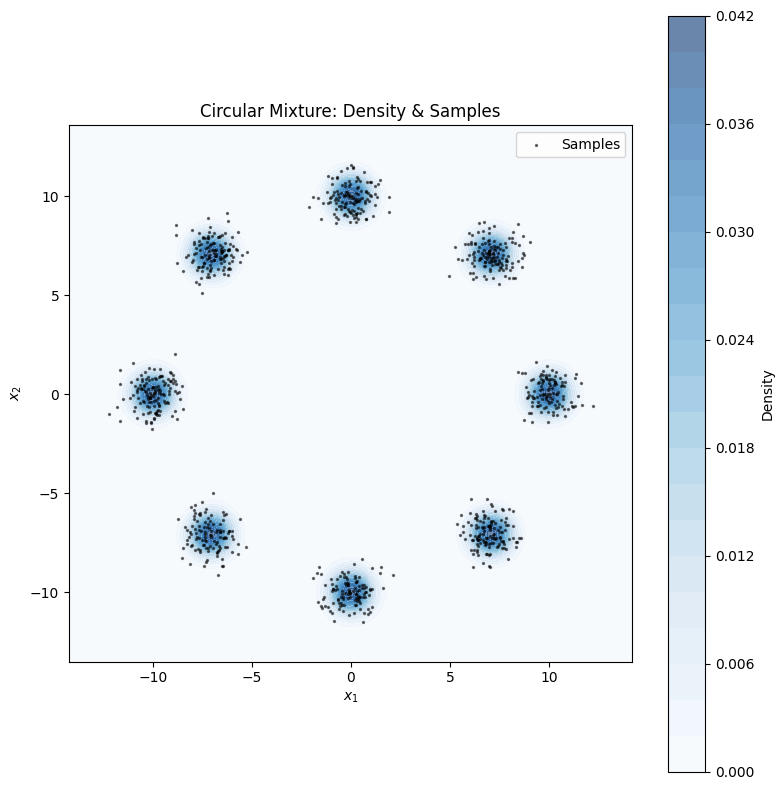

In [2]:
import matplotlib.pyplot as plt

# Initialize
mixture = CircularMixture()
key = jax.random.PRNGKey(42)

# Sample
n_samples = 1000
samples = mixture.sample(seed=key, sample_shape=(n_samples,))
print(f"Sample shape: {samples.shape}")  # (1000, 2)

# Log Probability
log_probs = mixture.log_prob(samples)
print(f"Log prob shape: {log_probs.shape}") # (1000,)

# Compute Density on a Grid
# Define bounds based on the samples to ensure we cover the area
x_min, x_max = samples[:, 0].min() - 2, samples[:, 0].max() + 2
y_min, y_max = samples[:, 1].min() - 2, samples[:, 1].max() + 2

# Create grid
resolution = 100
x = jnp.linspace(x_min, x_max, resolution)
y = jnp.linspace(y_min, y_max, resolution)
X, Y = jnp.meshgrid(x, y)

# Flatten grid to (N, 2) for log_prob evaluation
grid_points = jnp.stack([X.ravel(), Y.ravel()], axis=1)

# Evaluate log_prob and convert to density
log_probs = mixture.log_prob(grid_points)
density = jnp.exp(log_probs).reshape(X.shape)

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(8, 8))

# Contour plot for density
# Using 'viridis' or 'Blues' gives a clean look
contour = ax.contourf(X, Y, density, levels=20, cmap='Blues', alpha=0.6)

# Scatter plot for samples
# s=2 makes the points small enough not to obscure the density
ax.scatter(samples[:, 0], samples[:, 1], s=2, c='black', alpha=0.5, label='Samples')

# Formatting
ax.set_aspect('equal')
ax.set_title("Circular Mixture: Density & Samples")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(loc='upper right')

plt.colorbar(contour, ax=ax, label="Density")
plt.tight_layout()
plt.show()

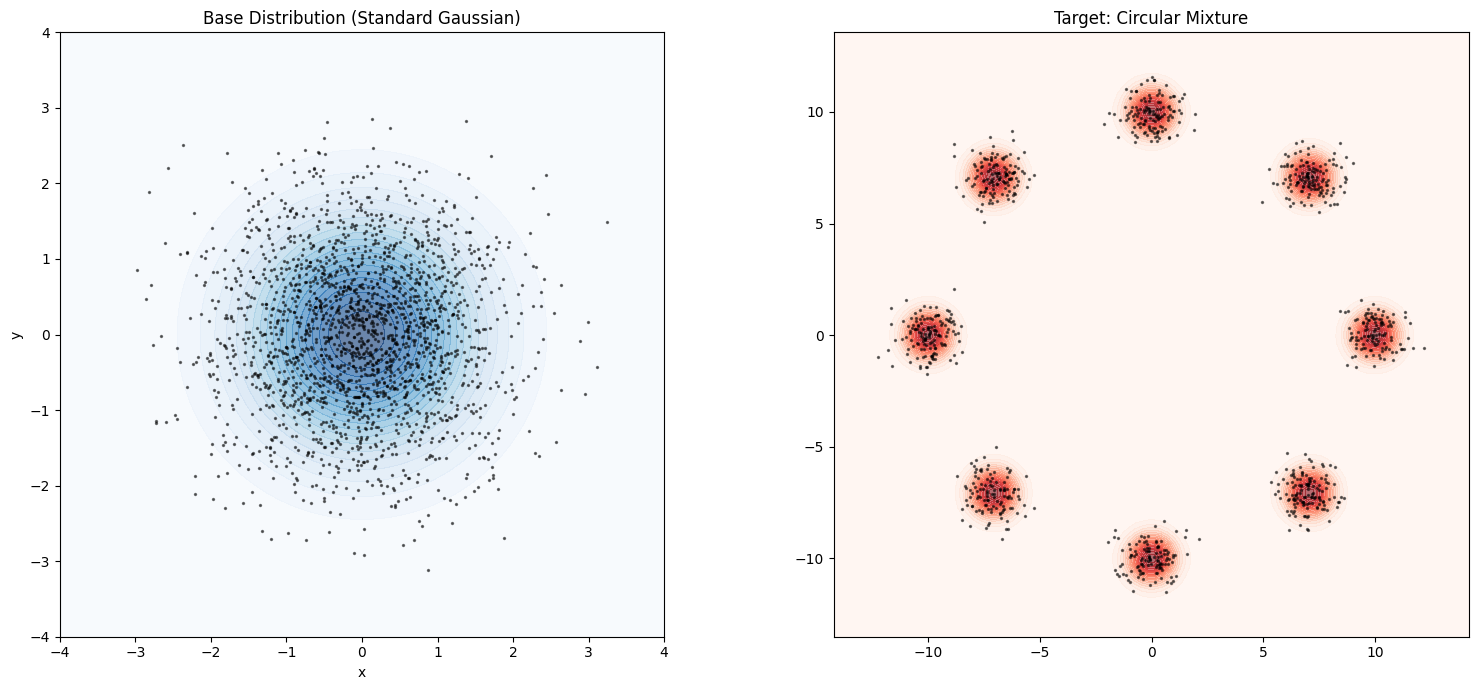

In [3]:
mu = jnp.zeros(2)
sigma = jnp.ones(2)
base_dist = dsx.MultivariateNormalDiag(mu, sigma)

# Sample
base_samples = base_dist.sample(seed=key, sample_shape=(2000,))

# Grid for Base Density (smaller range: -4 to 4)
x_base = jnp.linspace(-4, 4, 100)
y_base = jnp.linspace(-4, 4, 100)
X_base, Y_base = jnp.meshgrid(x_base, y_base)
grid_base = jnp.stack([X_base.ravel(), Y_base.ravel()], axis=1)

# Log Prob -> Density
base_log_probs = base_dist.log_prob(grid_base)
base_density = jnp.exp(base_log_probs).reshape(X_base.shape)


# --- 2. Plotting (Side-by-Side) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot Base Distribution (Left)
axes[0].contourf(X_base, Y_base, base_density, levels=20, cmap='Blues', alpha=0.6)
axes[0].scatter(base_samples[:, 0], base_samples[:, 1], s=2, c='black', alpha=0.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Base Distribution (Standard Gaussian)")
axes[0].set_aspect('equal')

# Plot Circular Mixture (Right)
# (Reuse your existing X, Y, density, samples logic here)
axes[1].contourf(X, Y, density, levels=20, cmap='Reds', alpha=0.6)
axes[1].scatter(samples[:, 0], samples[:, 1], s=2, c='black', alpha=0.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[1].set_title("Target: Circular Mixture")
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [18]:
class MLPVelocity(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, input_dim: int, width: int, depth: int, *, key):
        # Input is x plus one scalar time => input_dim + 1
        self.mlp = eqx.nn.MLP(
            in_size=input_dim + 1,
            out_size=input_dim,
            width_size=width,
            depth=depth,
            activation=jax.nn.tanh,
            key=key,
        )

    def __call__(self, t, x, args):
        # x shape (..., input_dim)
        # t is scalar; broadcast to match leading batch dims of x
        t_feat = jnp.broadcast_to(t, x.shape[:-1] + (1,))
        inp = jnp.concatenate([x, t_feat], axis=-1)
        return self.mlp(inp)


key, subkey = jax.random.split(key)
velocity_field = MLPVelocity(input_dim=2, width=16, depth=3, key=subkey)
flow = Flow(
        velocity_field=velocity_field,
        base_distribution=base_dist,
    )

key, subkey = jax.random.split(key)
flow.sample_and_log_prob(seed=subkey, sample_shape=(2000,))

(Array([[-0.09307748, -0.29195136],
        [ 0.5472707 , -2.2726157 ],
        [ 2.3218772 ,  0.10781273],
        ...,
        [-0.06167264, -0.96119696],
        [ 0.05609437, -0.4237149 ],
        [ 0.35127583,  1.8487422 ]], dtype=float32),
 Array([-1.9356928, -4.0895023, -4.706968 , ..., -2.1891088, -1.9551814,
        -3.920434 ], dtype=float32))

In [25]:
params, static = eqx.partition(flow, eqx.is_array)

ValueError: Mismatch custom node data: ([dtype('float32'), 2, True, True], [False, False, False, False], PyTreeDef({'_batch_shape': (), '_bijector': CustomNode(Chain[([1, 1, True, True], [False, False, False, False], PyTreeDef({'_bijectors': [CustomNode(Block[([1, 1, True, True, 1], [False, False, False, False, False], PyTreeDef({'_bijector': CustomNode(Shift[([2, 0, 0, True, True, True], [False, False, False, False, False, False], PyTreeDef({'_batch_shape': (*,), '_event_ndims_in': *, '_event_ndims_out': *, '_is_constant_jacobian': *, '_is_constant_log_det': *, '_shift': *}))], [None, None, None, None, None, None]), '_event_ndims_in': *, '_event_ndims_out': *, '_is_constant_jacobian': *, '_is_constant_log_det': *, '_ndims': *}))], [None, None, None, None, None]), CustomNode(DiagLinear[([True, dtype('float32'), 2, 1, 1, True, True, <bound method Block.forward of <distrax._src.bijectors.block.Block object at 0x1187dff50>>, <bound method Block.forward_log_det_jacobian of <distrax._src.bi

In [24]:
import optax


@eqx.filter_jit
def ml_loss(flow, batch):
    logq = flow.log_prob(batch)
    return -jnp.mean(logq)

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(flow)

@eqx.filter_jit
def train_step(flow, opt_state, batch):
    loss, grads = eqx.filter_value_and_grad(ml_loss)(flow, batch)
    updates, opt_state = optimizer.update(grads, opt_state)
    flow = eqx.apply_updates(flow, updates)
    return flow, opt_state, loss


TypeError: zeros_like requires ndarray or scalar arguments, got <class 'jaxlib._jax.PjitFunction'> at position 0.

## Jacobian test

In [12]:
import jax
import jax.numpy as jnp


def velocity_field(x):
    return x**2

key = jax.random.key(0)
key, subkey = jax.random.split(key)
x = jax.random.uniform(key, (4,2))

print(f'Velocity field shape: {velocity_field(x).shape}')

jax.jacfwd(velocity_field)(jnp.array([1.0, 2.0, 3.0]))

Velocity field shape: (4, 2)


Array([[2., 0., 0.],
       [0., 4., 0.],
       [0., 0., 6.]], dtype=float32)

In [21]:
jax.jacfwd(velocity_field)(x).shape

(4, 2, 4, 2)